# MLP (Multi Layer Perceptron)
This first implementation of the MLP is done through NumPy, rather than a more efficient and flexible object-oriented one, in order to be able to see each passage clearly.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

from models.mlp import MLP, binary_cross_entropy
import models.mlp_oop as O
from utils.plots import plot_decision_boundary, animate_mlp_decision_boundary
from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import utils.functions as F
from utils.tests import parameter_sweep_classification

## Tests

### Test Shapes

In [33]:
X_dummy = np.random.randn(32, 2)

mlp = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
)

mlp._initialize_parameters('random')

A2, cache = mlp.forward(X_dummy)

print("W1:", mlp.W1.shape)
print("b1:", mlp.b1.shape)
print("Z1:", cache["Z1"].shape)
print("A1:", cache["A1"].shape)
print("W2:", mlp.W2.shape)
print("b2:", mlp.b2.shape)
print("Z2:", cache["Z2"].shape)
print("A2:", A2.shape)

W1: (2, 8)
b1: (1, 8)
Z1: (32, 8)
A1: (32, 8)
W2: (8, 1)
b2: (1, 1)
Z2: (32, 1)
A2: (32, 1)


### Test Loss
Since we have not training the network and are using random tiny weights, the network outputs probabilities close to 0.5, and binary cross-entropy near random guessing is `-log(0.5) ≈ 0.693`

In [34]:
y_dummy = np.random.randint(0, 2, size=(32, 1))

loss = binary_cross_entropy(y_dummy, A2)

loss

np.float64(0.6931558804796221)

### Test Grads

In [35]:
grads = mlp.backward(X_dummy, y_dummy, cache)

for name, grad in grads.items():
    print(name, grad.shape)

dW1 (2, 8)
db1 (1, 8)
dW2 (8, 1)
db2 (1, 1)


### Test Update
Testing one update step on random dummy data, we see the loss changes very slightly. This is fine, because with tiny random weights, the gradients are very small, and one step barely moves anything. Still, the loss decreased, which means the gradients are in the right direction.

In [36]:
loss_before = binary_cross_entropy(y_dummy, A2)

grads = mlp.backward(X_dummy, y_dummy, cache)
mlp.update_parameters(grads, lr=0.1)

A2_after, cache_after = mlp.forward(X_dummy)
loss_after = binary_cross_entropy(y_dummy, A2_after)

print(loss_before)
print(loss_after)

0.6931558804796221
0.6931557446994474


### Test Fit
Since dummy data is random, there is no real pattern to learn, therefore the loss can only be reduced slightly by exploiting accidental correlations. However the decrease is smooth, so the training loop works.

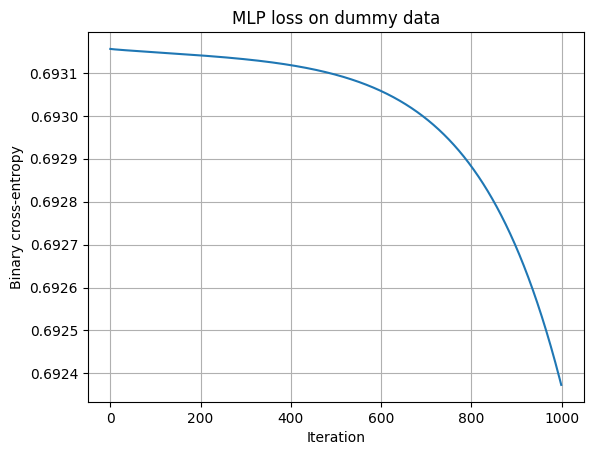

In [37]:
mlp = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    lr=0.1, 
    n_iters=1000
)

mlp.fit(X_dummy, y_dummy)

plt.plot(mlp.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("MLP loss on dummy data")
plt.grid(True)
plt.show()

## Moons Dataset

In [38]:
# Generation
X, y = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

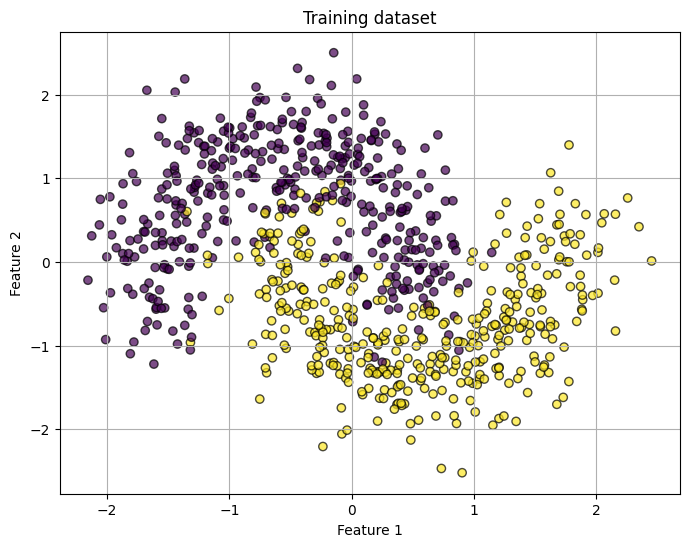

In [39]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

### Training
Looking at the combinations of activation + initialization, we can see that 
- **sigmoid + xavier**: the model has an accuracy of 0.92. Looking at the decision boundary plot, we see that it has a slight curvature, but it is still mostly linear
- **tanh + xavier**: the model has an accuracy of 0.96. The decision boundary has a definite curve, and the model has managed to adapt much better to the dataset, as is testified by the loss plot, which goes much lower than in the other models
- **tanh + random**: the model has an accuracy of 0.92, and in general the metrics are the same as the sigmoid + xavier model. This is easy to understand by looking at the decision boundary, which is fully linear, very similar to the one of the first model. This depends on the fact that, initializing the weights in random mode, they are very close to 0, therefore the activation function still behaves mostly linearly in that region, and the model stays linear unless the dataset has very strong nonlinear features. Since for this dataset we can still reach a high accuracy with a linear boundary, the model has no incentive to change the weights further. 

It is noted that by raising the learning rate (to at least 1.5 or so) we can get the curved boundary even for the **tanh + random** model, and an accuracy even higher than **tanh + xavier** (0.97). This is due to the fact that raising the `lr` forces the weights to change strongly even if the gradients are small, therefore sooner or later we get to the nonlinear region of the activation function, and the model adapts the nonlinear boundary. 

However, raising the lr too much is not indicated, as it may make gradients explode and destabilize training. The safest option is still **tanh + xavier** with a reasonable learning rate.

In [53]:
results = {}

# Sigmoid
mlp_sigmoid = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='sigmoid',
    lr=0.1, 
    n_iters=2000,
    initialization='xavier'
)

start = perf_counter()
mlp_sigmoid.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_sigmoid.predict(X_test_scaled)
predict_time = perf_counter() - start

results['sigmoid'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_sigmoid.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# Tanh
mlp_tanh = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, 
    n_iters=2000,
    initialization='xavier'
)

start = perf_counter()
mlp_tanh.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_tanh.predict(X_test_scaled)
predict_time = perf_counter() - start

results['tanh'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_tanh.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# Tanh (random initialization)
mlp_tanh_rand = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, # 1.5
    n_iters=2000,
    initialization='random'
)

start = perf_counter()
mlp_tanh_rand.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_tanh_rand.predict(X_test_scaled)
predict_time = perf_counter() - start

results['tanh_rand'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_tanh_rand.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,final_loss,Fit time,Predict time
sigmoid,0.92,0.946809,0.89,0.917526,0.329953,0.500715,0.000121
tanh,0.96,0.960000,0.96,0.960000,0.199602,0.449164,0.000137
tanh_rand,0.92,0.946809,0.89,0.917526,0.329979,0.533010,0.000118


### Loss Plot

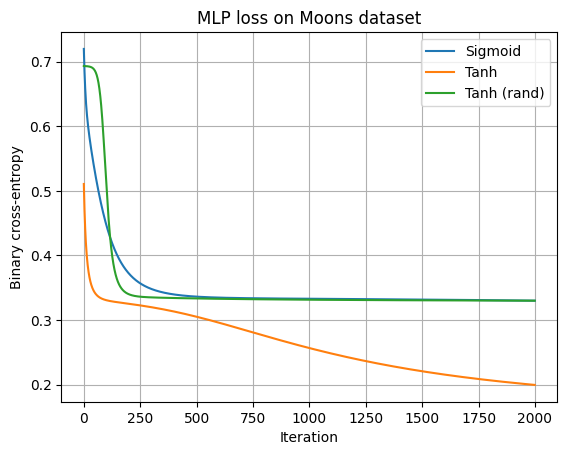

In [54]:
plt.plot(mlp_sigmoid.loss_history, label='Sigmoid')
plt.plot(mlp_tanh.loss_history, label='Tanh')
plt.plot(mlp_tanh_rand.loss_history, label='Tanh (rand)')
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("MLP loss on Moons dataset")
plt.grid(True)
plt.legend()
plt.show()

### Decision Boundary Plot

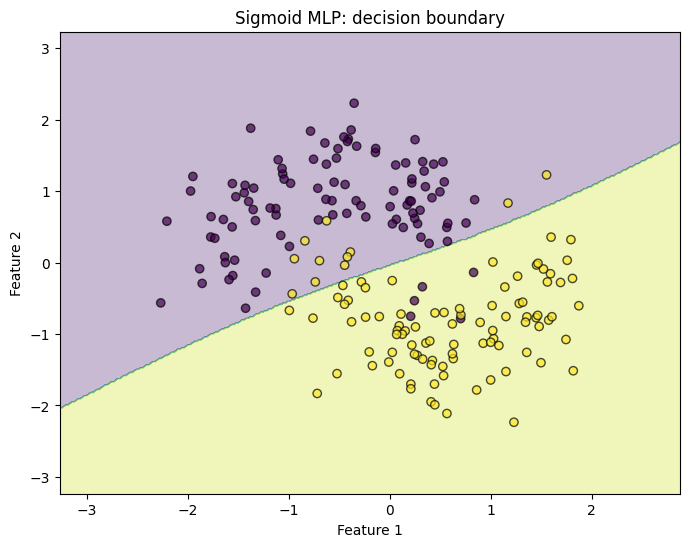

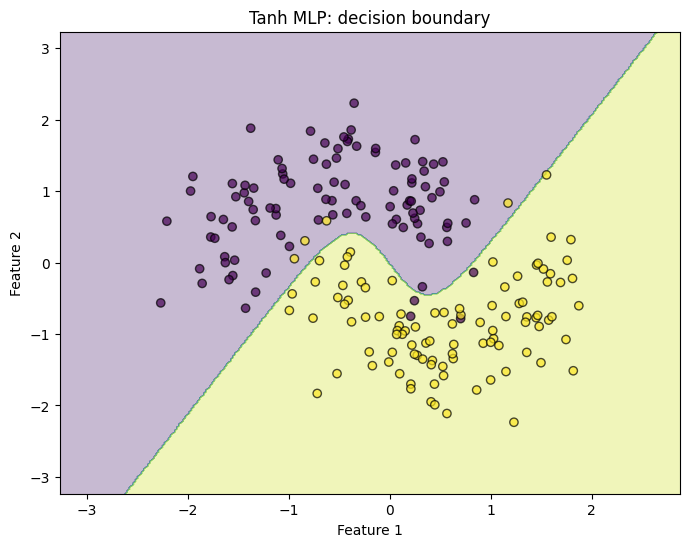

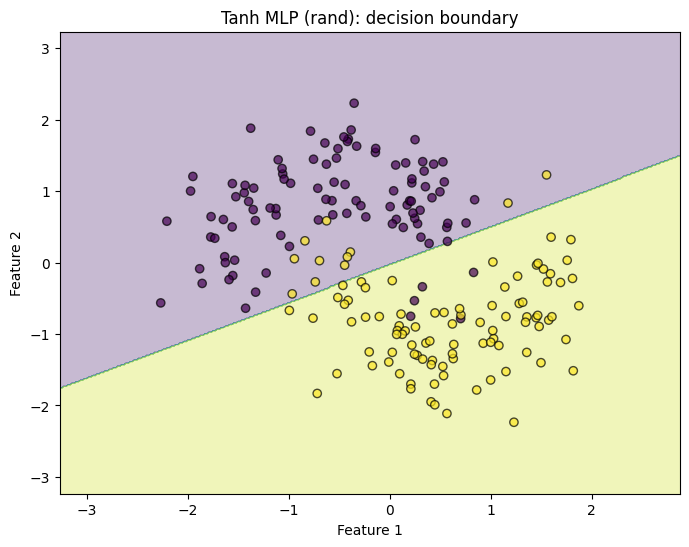

In [55]:
plot_decision_boundary(
    mlp_sigmoid,
    X_test_scaled,
    y_test,
    "Sigmoid MLP: decision boundary"
)

plot_decision_boundary(
    mlp_tanh,
    X_test_scaled,
    y_test,
    "Tanh MLP: decision boundary"
)

plot_decision_boundary(
    mlp_tanh_rand,
    X_test_scaled,
    y_test,
    "Tanh MLP (rand): decision boundary"
)

### Parameter Sweeps

#### Hidden Layer Width

In [43]:
hidden_sizes = [1, 2, 4, 8, 16, 32, 64]

sweep_results, loss_curves, models = parameter_sweep_classification(
    model_cls=MLP, 
    param_grid={
        'hidden_size': hidden_sizes,
        'hidden_activation':['sigmoid', 'tanh'],
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={
        'input_size':2,
        'output_size':1,
        'random_state':42,
        'lr':0.1,
        'n_iters':2000,
        'threshold':0.5,
        'initialization':'xavier'
    })

sweep_df = pd.DataFrame(sweep_results)
sigmoid_df = sweep_df[sweep_df['hidden_activation']=='sigmoid']
tanh_df = sweep_df[sweep_df['hidden_activation']=='tanh']

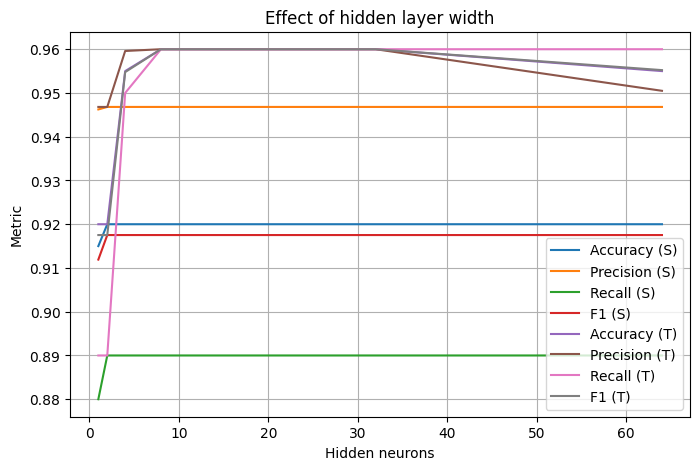

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_accuracy"], label="Accuracy (S)")
plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_precision"], label="Precision (S)")
plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_recall"], label="Recall (S)")
plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_f1"], label="F1 (S)")

plt.plot(tanh_df["hidden_size"], tanh_df["test_accuracy"], label="Accuracy (T)")
plt.plot(tanh_df["hidden_size"], tanh_df["test_precision"], label="Precision (T)")
plt.plot(tanh_df["hidden_size"], tanh_df["test_recall"], label="Recall (T)")
plt.plot(tanh_df["hidden_size"], tanh_df["test_f1"], label="F1 (T)")

plt.xlabel("Hidden neurons")
plt.ylabel("Metric")
plt.title("Effect of hidden layer width")
plt.legend()
plt.grid(True)

plt.show()

## Circles Dataset 
This dataset cannot be modeled with a linear boundary, therefore this is a demonstration that this model handles nonlinear boundaries well.

In [3]:
from sklearn.datasets import make_circles

# Generation
X, y = make_circles(
    n_samples=1000,
    noise=0.12,
    factor=0.4,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

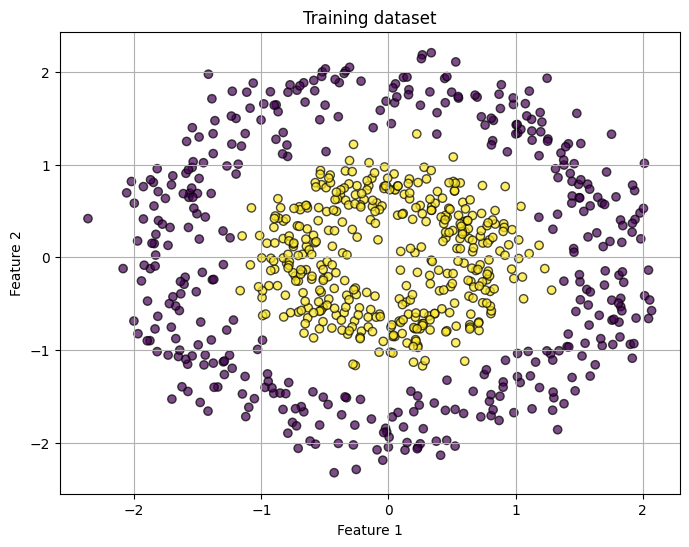

In [4]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

### Training

In [88]:
results = {}

# Sigmoid
mlp_sigmoid = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='sigmoid',
    lr=0.1, 
    n_iters=2000,
    initialization='xavier'
)

start = perf_counter()
mlp_sigmoid.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_sigmoid.predict(X_test_scaled)
predict_time = perf_counter() - start

results['sigmoid'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_sigmoid.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# Tanh
mlp_tanh = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, 
    n_iters=2000,
    initialization='xavier'
)

start = perf_counter()
mlp_tanh.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_tanh.predict(X_test_scaled)
predict_time = perf_counter() - start

results['tanh'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_tanh.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# Tanh (random initialization)
mlp_tanh_rand = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, # 1.5
    n_iters=2000,
    initialization='random'
)

start = perf_counter()
mlp_tanh_rand.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_tanh_rand.predict(X_test_scaled)
predict_time = perf_counter() - start

results['tanh_rand'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_tanh_rand.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,final_loss,Fit time,Predict time
sigmoid,0.830,0.750000,0.99,0.853448,0.600095,0.525769,0.000378
tanh,0.995,0.990099,1.00,0.995025,0.087837,0.521896,0.000202
tanh_rand,0.510,0.509804,0.52,0.514851,0.693147,0.519578,0.000300


### Loss Plot

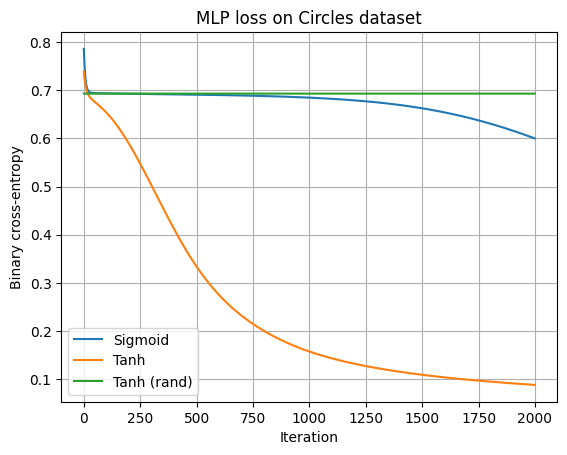

In [89]:
plt.plot(mlp_sigmoid.loss_history, label='Sigmoid')
plt.plot(mlp_tanh.loss_history, label='Tanh')
plt.plot(mlp_tanh_rand.loss_history, label='Tanh (rand)')
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("MLP loss on Circles dataset")
plt.grid(True)
plt.legend()
plt.show()

### Decision Boundary Plot

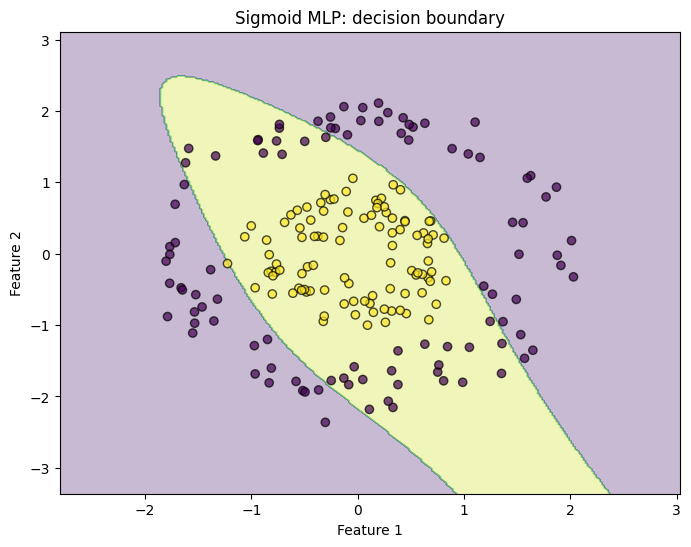

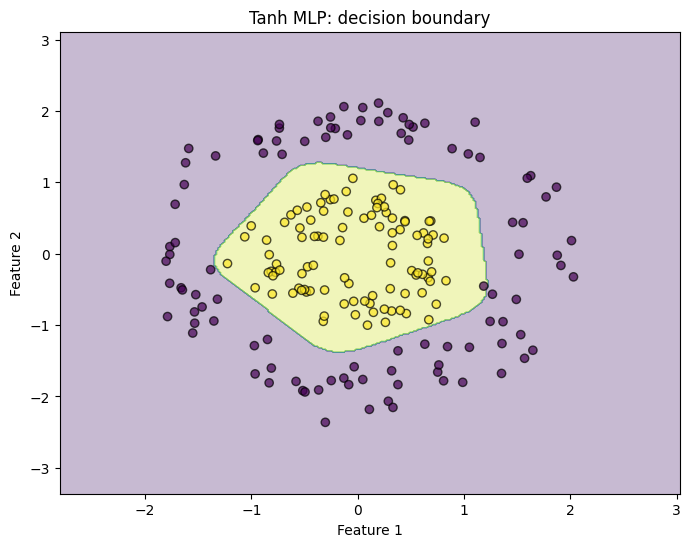

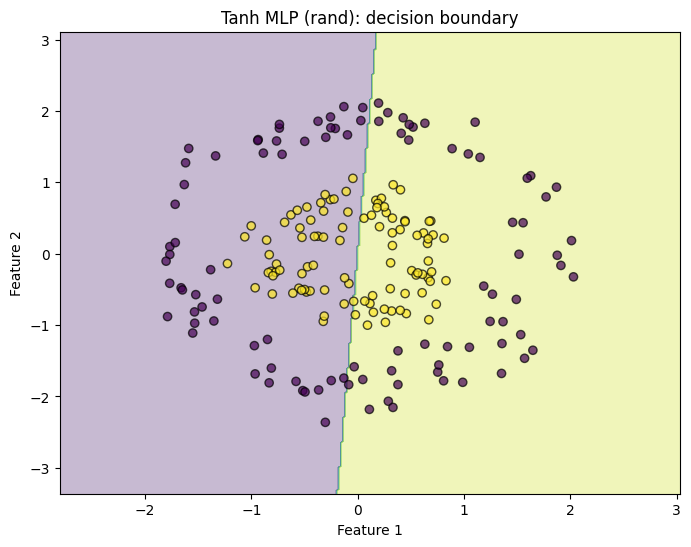

In [90]:
plot_decision_boundary(
    mlp_sigmoid,
    X_test_scaled,
    y_test,
    "Sigmoid MLP: decision boundary"
)

plot_decision_boundary(
    mlp_tanh,
    X_test_scaled,
    y_test,
    "Tanh MLP: decision boundary"
)

plot_decision_boundary(
    mlp_tanh_rand,
    X_test_scaled,
    y_test,
    "Tanh MLP (rand): decision boundary"
)

### Parameter Sweeps

#### Hidden Layer Width
We can see that 4 neurons is apparently the optimal width for the sigmoid MLP, after which performance degrades. To obtain a fairer result, we would need to average over multiple random states, but already we can conclude that
- Sigmoid:
    - good at 4
    - degrades steadily

- Tanh:
    - reaches ~1.0
    - stays there

and this is consistent with what we know theoretically, as sigmoid hidden units suffer more from saturation and vanishing gradients, therefore as width increases, there are more parameters and the optimization becomes harder, thus the sigmoid starts struggling.
On the other hand, tanh is zero-centered, so optimization remains healthier.

In [61]:
hidden_sizes = [1, 2, 4, 8, 16, 32, 64]

sweep_results, loss_curves, models = parameter_sweep_classification(
    model_cls=MLP, 
    param_grid={
        'hidden_size': hidden_sizes,
        'hidden_activation':['sigmoid', 'tanh'],
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={
        'input_size':2,
        'output_size':1,
        'random_state':42,
        'lr':0.1,
        'n_iters':2000,
        'threshold':0.5,
        'initialization':'xavier'
    })

sweep_df = pd.DataFrame(sweep_results)
sigmoid_df = sweep_df[sweep_df['hidden_activation']=='sigmoid']
tanh_df = sweep_df[sweep_df['hidden_activation']=='tanh']

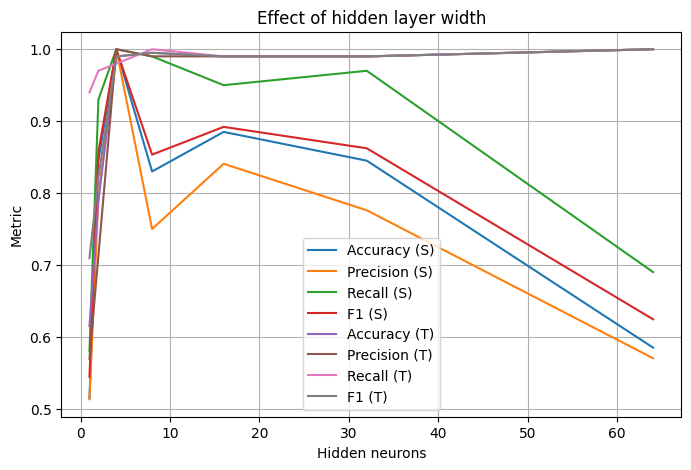

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_accuracy"], label="Accuracy (S)")
plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_precision"], label="Precision (S)")
plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_recall"], label="Recall (S)")
plt.plot(sigmoid_df["hidden_size"], sigmoid_df["test_f1"], label="F1 (S)")

plt.plot(tanh_df["hidden_size"], tanh_df["test_accuracy"], label="Accuracy (T)")
plt.plot(tanh_df["hidden_size"], tanh_df["test_precision"], label="Precision (T)")
plt.plot(tanh_df["hidden_size"], tanh_df["test_recall"], label="Recall (T)")
plt.plot(tanh_df["hidden_size"], tanh_df["test_f1"], label="F1 (T)")

plt.xlabel("Hidden neurons")
plt.ylabel("Metric")
plt.title("Effect of hidden layer width")
plt.legend()
plt.grid(True)

plt.show()

#### Learning Rate
Learning rate mainly affects optimization stability/speed, not final performance, within a broad stable range. Lower learning rates show suboptimal results, but likely because the model needs more iterations to converge.

However, sigmoid becomes unstable/degrades earlier while tanh remains stable longer, which reinforces that tanh gives healthier hidden-layer optimization than sigmoid.

Metric curves do not have to be monotonic because loss is optimized continuously, while accuracy/F1 are thresholded and discrete

In [81]:
lr_values = np.logspace(-5, 1, 40)

sweep_results, loss_curves, models = parameter_sweep_classification(
    model_cls=MLP, 
    param_grid={
        'lr': lr_values,
        'hidden_activation':['sigmoid', 'tanh'],
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={
        'input_size':2,
        'output_size':1,
        'random_state':42,
        'hidden_size':8,
        'n_iters':2000,
        'threshold':0.5,
        'initialization':'xavier'
    })

sweep_df = pd.DataFrame(sweep_results)
sigmoid_df = sweep_df[sweep_df['hidden_activation']=='sigmoid']
tanh_df = sweep_df[sweep_df['hidden_activation']=='tanh']

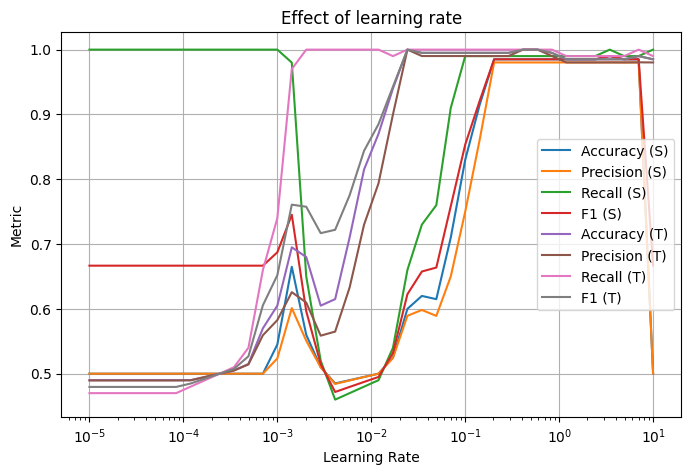

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(sigmoid_df["lr"], sigmoid_df["test_accuracy"], label="Accuracy (S)")
plt.plot(sigmoid_df["lr"], sigmoid_df["test_precision"], label="Precision (S)")
plt.plot(sigmoid_df["lr"], sigmoid_df["test_recall"], label="Recall (S)")
plt.plot(sigmoid_df["lr"], sigmoid_df["test_f1"], label="F1 (S)")

plt.plot(tanh_df["lr"], tanh_df["test_accuracy"], label="Accuracy (T)")
plt.plot(tanh_df["lr"], tanh_df["test_precision"], label="Precision (T)")
plt.plot(tanh_df["lr"], tanh_df["test_recall"], label="Recall (T)")
plt.plot(tanh_df["lr"], tanh_df["test_f1"], label="F1 (T)")

plt.xlabel("Learning Rate")
plt.ylabel("Metric")
plt.title("Effect of learning rate")
plt.legend()
plt.xscale("log")
plt.grid(True)

plt.show()

### Decision Boundary Animation

In [98]:
from IPython.display import HTML

snapshot_iters = list(range(0, 2001, 50))

mlp_tanh = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, 
    n_iters=2001,
    initialization='xavier'
)

snapshots = mlp_tanh.fit(
    X_train_scaled,
    y_train,
    snapshot_iters=snapshot_iters,
)

In [102]:
anim = animate_mlp_decision_boundary(mlp_tanh, snapshots, X_test_scaled, y_test)
HTML(anim.to_jshtml())

### PyTorch Comparison
We can see that using the same architecture and optimizer on the same task, with our NumPy MLP implementation and a fully PyTorch one, gives similar learning dynamics and similar final performance. This testifies that our implementation is correct.

In [104]:
comparison = {}

# Scratch Tanh 
mlp_tanh = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, 
    n_iters=2000,
    initialization='xavier'
)

start = perf_counter()
mlp_tanh.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_tanh.predict(X_test_scaled)
predict_time = perf_counter() - start

comparison['NumPy MLP'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_tanh.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# PyTorch Tanh
torch_mlp = nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(torch_mlp.parameters(), lr=0.1)

# Training
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

torch_loss_history = []

start = perf_counter()
for _ in range(2000):
    logits = torch_mlp(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    torch_loss_history.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
fit_time = perf_counter() - start

# Prediction
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

start = perf_counter()
with torch.no_grad():
    logits = torch_mlp(X_test_tensor)
    torch_proba = torch.sigmoid(logits).numpy().ravel()
    torch_preds = (torch_proba >= 0.5).astype(int)
predict_time = perf_counter() - start

comparison['PyTorch MLP'] = {
    "Accuracy": accuracy_score(y_test, torch_preds),
    "Precision": precision_score(y_test, torch_preds),
    "Recall": recall_score(y_test, torch_preds),
    "F1": f1_score(y_test, torch_preds),
    "final_loss": torch_loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

pd.DataFrame(comparison).T

,Accuracy,Precision,Recall,F1,final_loss,Fit time,Predict time
NumPy MLP,0.995,0.990099,1.00,0.995025,0.087837,0.479516,0.000174
PyTorch MLP,0.990,1.000000,0.98,0.989899,0.106560,1.314369,0.006688


#### Loss Plot

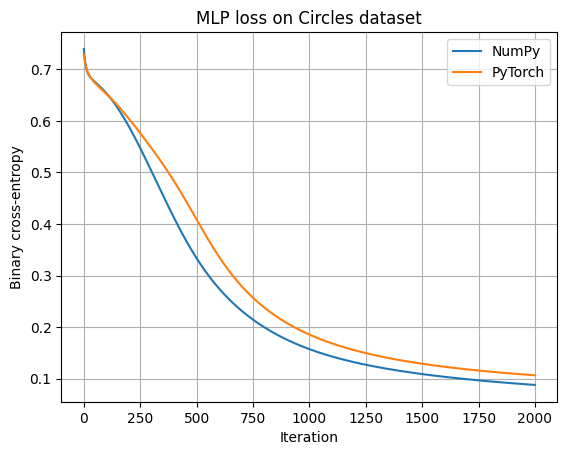

In [105]:
plt.plot(mlp_tanh.loss_history, label='NumPy')
plt.plot(torch_loss_history, label='PyTorch')
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("MLP loss on Circles dataset")
plt.grid(True)
plt.legend()
plt.show()

#### Decision Boundary Plots

In [106]:
class TorchMLPWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)

        with torch.no_grad():
            logits = self.model(X_tensor)
            proba = torch.sigmoid(logits).numpy().ravel()

        return (proba >= 0.5).astype(int)

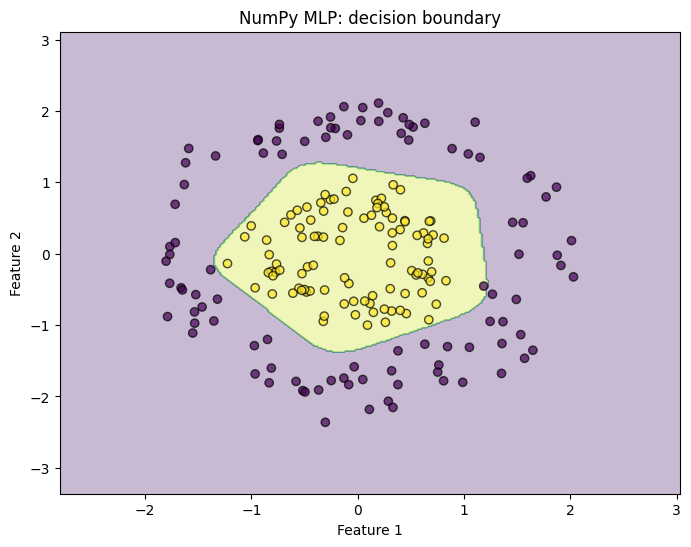

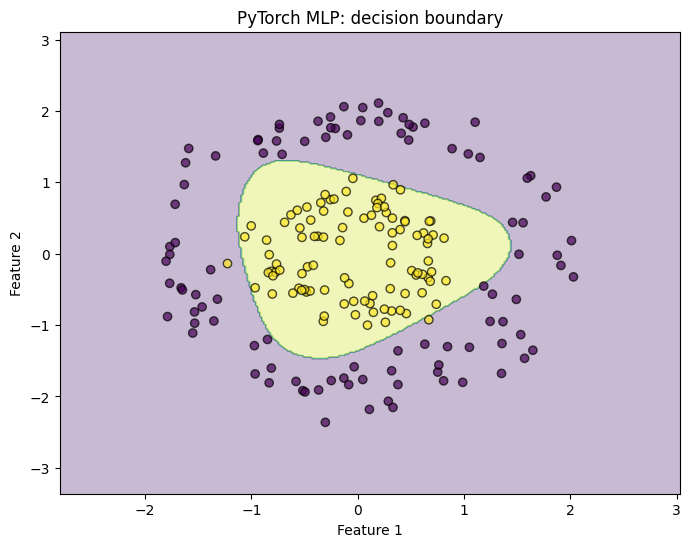

In [107]:
torch_wrapper = TorchMLPWrapper(torch_mlp)

plot_decision_boundary(
    mlp_tanh,
    X_test_scaled,
    y_test,
    "NumPy MLP: decision boundary"
)

plot_decision_boundary(
    torch_wrapper,
    X_test_scaled,
    y_test,
    "PyTorch MLP: decision boundary"
)

## OOP MLP Comparison
The loss and metrics are almost identical between the NumPy implementation and the OOP implementation closer to how PyTorch works, therefore the OOP implementation is correct.

In [111]:
from sklearn.datasets import make_circles

# Generation
X, y = make_circles(
    n_samples=1000,
    noise=0.12,
    factor=0.4,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
results = {}

# NumPy Tanh
mlp_tanh = MLP(
    input_size=2,
    hidden_size=8,
    output_size=1,
    random_state=42,
    hidden_activation='tanh',
    lr=0.1, 
    n_iters=2000,
    initialization='xavier'
)

start = perf_counter()
mlp_tanh.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
preds = mlp_tanh.predict(X_test_scaled)
predict_time = perf_counter() - start

results['NumPy tanh'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": mlp_tanh.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# MLP Tanh 
oop_mlp = O.Sequential(
    O.Linear(2, 8, init_method='xavier', random_state=42),
    O.Tanh(),
    O.Linear(8, 1, init_method='xavier', random_state=43),
    O.Sigmoid(),
)

loss_fn = O.BinaryCrossEntropy()

start = perf_counter()
oop_mlp.fit(
    X_train_scaled,
    y_train,
    loss_fn=loss_fn,
    lr=0.1,
    n_iters=2000
)
fit_time = perf_counter() - start

start = perf_counter()
preds = oop_mlp.predict(X_test_scaled)
predict_time = perf_counter() - start

results['OOP tanh'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds),
    "Recall": recall_score(y_test, preds),
    "F1": f1_score(y_test, preds),
    "final_loss": oop_mlp.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,final_loss,Fit time,Predict time
NumPy tanh,0.995,0.990099,1.0,0.995025,0.087837,0.487323,0.000120
OOP tanh,1.000,1.000000,1.0,1.000000,0.081448,0.507838,0.000113


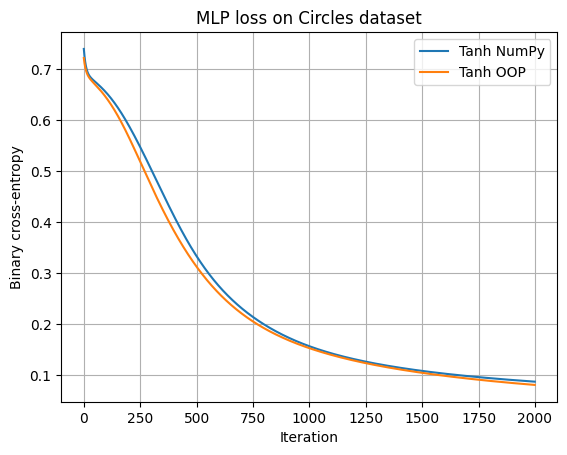

In [6]:
plt.plot(mlp_tanh.loss_history, label='Tanh NumPy')
plt.plot(oop_mlp.loss_history, label='Tanh OOP')
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("MLP loss on Circles dataset")
plt.grid(True)
plt.legend()
plt.show()

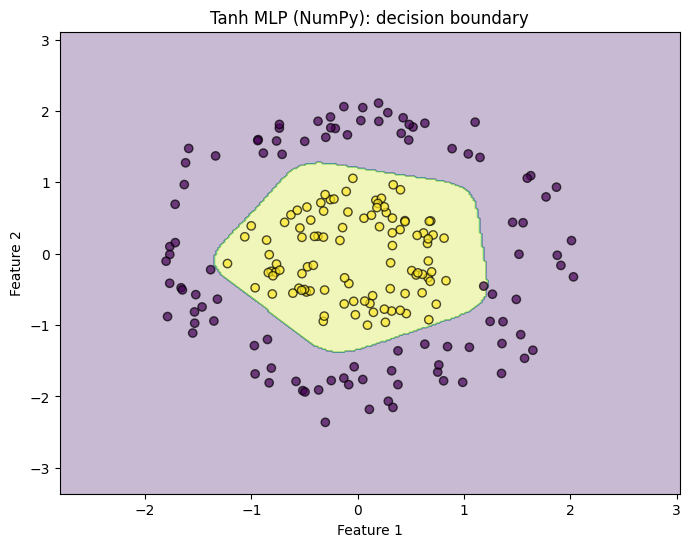

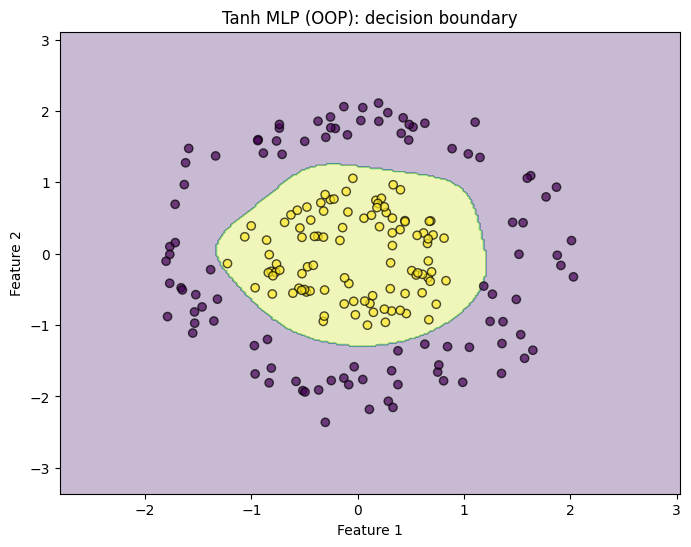

In [7]:
plot_decision_boundary(
    mlp_tanh,
    X_test_scaled,
    y_test,
    "Tanh MLP (NumPy): decision boundary"
)

plot_decision_boundary(
    oop_mlp,
    X_test_scaled,
    y_test,
    "Tanh MLP (OOP): decision boundary"
)